# Gibbs Sampling via Reparametrization
## Problem: Joint Distribution of X and Y = X²

### Setup

$$X \sim \text{Uniform}(-2,\,2), \qquad Y = X^2$$

**The challenge:** Sampling $X$ from a Uniform distribution is trivial. However, directly sampling $Y$ from its marginal distribution — which has density $f_Y(y) = \frac{1}{4\sqrt{y}}$ (singular near 0) — or sampling from the conditional $X \mid Y$ is not straightforward.

**Gibbs sampling** resolves this by alternating between the two conditionals, both of which are easy:

| Conditional | Distribution |
|-------------|-------------|
| $Y \mid X = x$ | Deterministic: $Y = x^2$ (point mass) |
| $X \mid Y = y$ | Discrete: $X = +\sqrt{y}$ or $-\sqrt{y}$, each with probability $\tfrac{1}{2}$ |

The second conditional follows because $X^2 = y$ has exactly two solutions in $[-2,2]$, and $\text{Uniform}(-2,2)$ assigns equal weight to $+\sqrt{y}$ and $-\sqrt{y}$.

### True Marginal Densities

$$f_X(x) = \frac{1}{4}, \quad x \in [-2,2]$$

$$f_Y(y) = \frac{d}{dy}\,P(X^2 \le y) = \frac{d}{dy}\frac{\sqrt{y}}{2} = \frac{1}{4\sqrt{y}}, \quad y \in [0,4]$$

### Algorithm

```
Initialize X₀  (any value in [-2, 2])

For t = 1, 2, ..., N:
    Step 1 — Sample  Y_t | X_{t-1}:   Y_t  =  X_{t-1}²            (deterministic)
    Step 2 — Sample  X_t | Y_t:        X_t  =  +√Y_t  with prob 0.5
                                              =  −√Y_t  with prob 0.5
```


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [10]:
def gibbs_sampler(n_samples: int, burn_in: int = 500, x_init: float = 1.0):
    """
    Gibbs sampler for the joint distribution of (X, Y) where:
        X ~ Uniform(-2, 2)
        Y = X^2

    Conditional distributions
    -------------------------
    Y | X = x  ->  deterministic : Y = x^2
    X | Y = y  ->  discrete      : X = +sqrt(y) or -sqrt(y), each w.p. 0.5

    Parameters
    ----------
    n_samples : int    Number of post-burn-in samples to collect.
    burn_in   : int    Samples to discard for Markov chain warm-up.
    x_init    : float  Starting value of X.

    Returns
    -------
    xs, ys : ndarrays of shape (n_samples,)
    """
    xs = np.empty(n_samples)
    ys = np.empty(n_samples)

    idx = 0

    for t in range(n_samples + burn_in):
        x = np.random.uniform(-2, 2)  # Initialize X at t=0
        # Step 1: Sample Y | X  (deterministic)
        y = x ** 2

        if t >= burn_in:
            xs[idx] = x
            ys[idx] = y
            idx += 1

    return xs, ys


N = 50_000
xs, ys = gibbs_sampler(N, burn_in=500)

print(f"Samples collected : {N:,}")
print()
print(f"E[X]   = {xs.mean():+.4f}   (true:  0.0000)")
print(f"Std[X] =  {xs.std():.4f}   (true:  {np.sqrt(4/3):.4f}  = sqrt(4/3))")
print(f"E[Y]   =  {ys.mean():.4f}   (true:  {4/3:.4f}  = E[X²])")

Samples collected : 50,000

E[X]   = +0.0065   (true:  0.0000)
Std[X] =  1.1555   (true:  1.1547  = sqrt(4/3))
E[Y]   =  1.3353   (true:  1.3333  = E[X²])


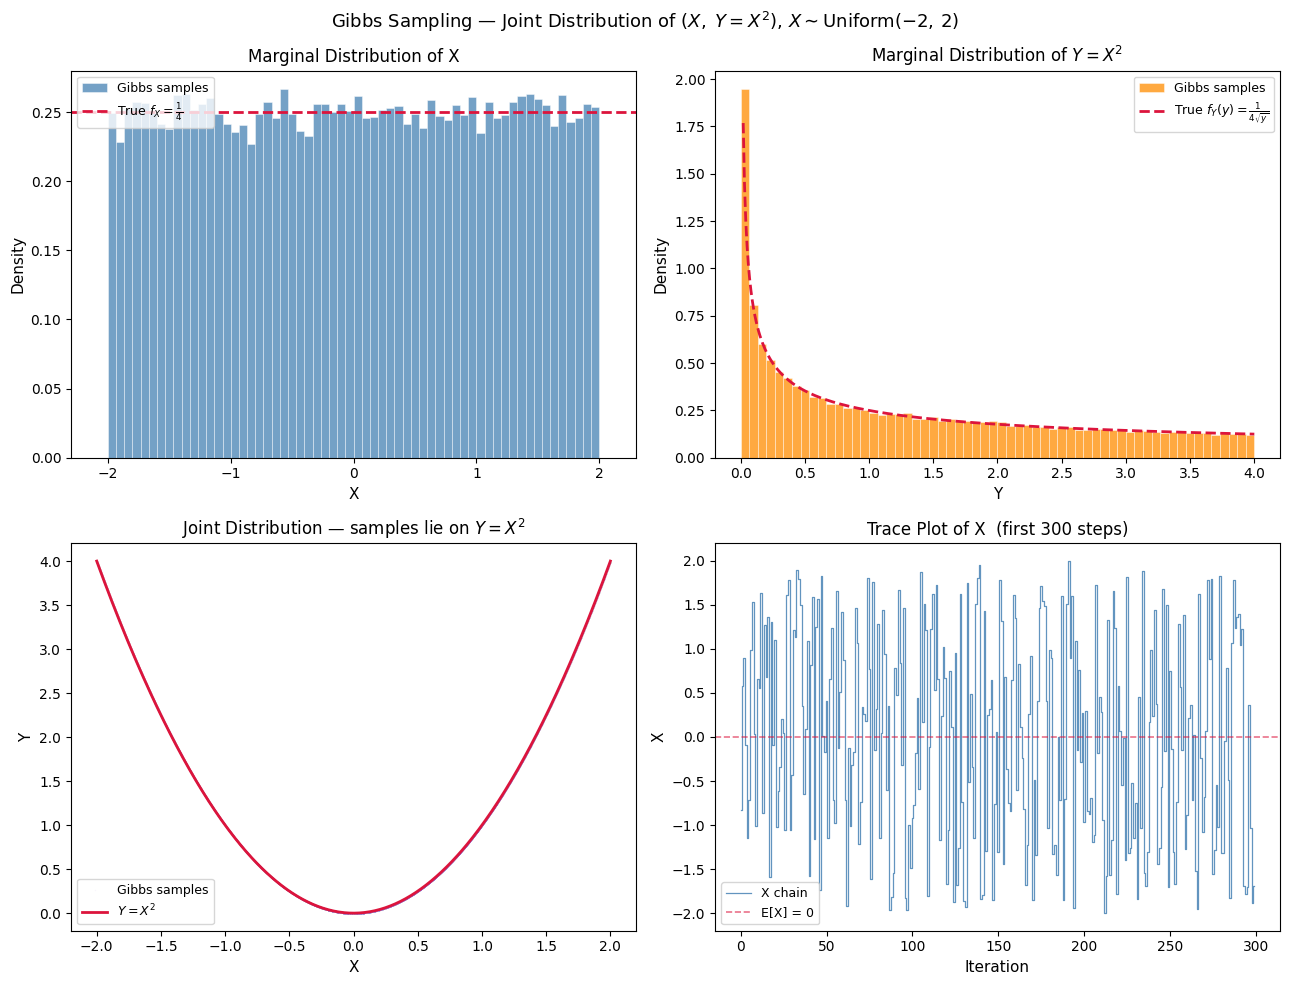

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(
    r"Gibbs Sampling — Joint Distribution of $(X,\; Y = X^2)$, "
    r"$X \sim \mathrm{Uniform}(-2,\,2)$",
    fontsize=13,
)

# ── 1. Marginal of X ─────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(xs, bins=60, density=True, color="steelblue", alpha=0.75,
        edgecolor="white", linewidth=0.4, label="Gibbs samples")
ax.axhline(0.25, color="crimson", lw=2, ls="--",
           label=r"True $f_X = \frac{1}{4}$")
ax.set_xlim(-2.3, 2.3)
ax.set_xlabel("X", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Marginal Distribution of X", fontsize=12)
ax.legend(fontsize=9)

# ── 2. Marginal of Y ─────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(ys, bins=60, density=True, color="darkorange", alpha=0.75,
        edgecolor="white", linewidth=0.4, label="Gibbs samples")
y_grid = np.linspace(0.02, 4, 400)
ax.plot(y_grid, 1 / (4 * np.sqrt(y_grid)), color="crimson", lw=2, ls="--",
        label=r"True $f_Y(y) = \frac{1}{4\sqrt{y}}$")
ax.set_xlabel("Y", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(r"Marginal Distribution of $Y = X^2$", fontsize=12)
ax.legend(fontsize=9)

# ── 3. Joint scatter ──────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(xs, ys, s=1, alpha=0.06, color="mediumpurple", linewidths=0,
           label="Gibbs samples")
x_curve = np.linspace(-2, 2, 400)
ax.plot(x_curve, x_curve ** 2, color="crimson", lw=2, label=r"$Y = X^2$")
ax.set_xlabel("X", fontsize=11)
ax.set_ylabel("Y", fontsize=11)
ax.set_title(r"Joint Distribution — samples lie on $Y = X^2$", fontsize=12)
ax.legend(fontsize=9)

# ── 4. Trace plot ─────────────────────────────────────────────────────────────
ax = axes[1, 1]
n_trace = 300
ax.step(range(n_trace), xs[:n_trace], where="mid",
        color="steelblue", lw=0.9, alpha=0.85, label="X chain")
ax.axhline(0, color="crimson", lw=1.2, ls="--", alpha=0.6, label="E[X] = 0")
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("X", fontsize=11)
ax.set_title(f"Trace Plot of X  (first {n_trace} steps)", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

With Reparametrization:
- Iinitialize starting values for u and v using uniform distribution within the range [0,1]
- Reparametrize u and v to the range of x and y
- x from (4*u-2) & y from (2*v-1)*x
- Implement Gibbs sampling iterations:
    - Sample u from its conditional distribution given v
    - Sample v from its conditional distribution given u
    - Reparametrize u and v to the range of x and y
    - Store the samples in the respective arrays
    - plot all the data obtained

In [12]:
def gibbs_reparametrized(n_samples: int, burn_in: int = 500):
    """
    Gibbs sampler for (X, Y) using reparametrization:

        u, v ~ Uniform(0, 1)
        x = 4*u - 2          maps [0,1] -> [-2, 2]
        y = (2*v - 1) * x    maps [0,1] -> [-|x|, |x|]

    In (u, v) space both conditionals are Uniform(0,1), so each
    Gibbs step is a trivial uniform draw.

    Parameters
    ----------
    n_samples : int   Post-burn-in samples to collect.
    burn_in   : int   Warm-up iterations to discard.

    Returns
    -------
    xs, ys : ndarrays of shape (n_samples,)
    """
    xs = np.empty(n_samples)
    ys = np.empty(n_samples)

    # Initialize u and v from Uniform(0, 1)
    u = np.random.uniform(0, 1)
    v = np.random.uniform(0, 1)

    idx = 0
    for t in range(n_samples + burn_in):
        # Sample u | v ~ Uniform(0, 1)  (conditionals are independent uniforms)
        u = np.random.uniform(0, 1)

        # Sample v | u ~ Uniform(0, 1)
        v = np.random.uniform(0, 1)

        # Reparametrize back to (x, y)
        x = 4 * u - 2
        y = (2 * v - 1) * x

        if t >= burn_in:
            xs[idx] = x
            ys[idx] = y
            idx += 1

    return xs, ys


N = 50_000
xs, ys = gibbs_reparametrized(N, burn_in=500)

print(f"Samples collected : {N:,}")
print()
print(f"E[X]   = {xs.mean():+.4f}   (true:  0.0000)")
print(f"Std[X] =  {xs.std():.4f}   (true:  {np.sqrt(4/3):.4f}  = sqrt(4/3))")
print(f"E[Y]   = {ys.mean():+.4f}   (true:  0.0000,  symmetric about 0)")

Samples collected : 50,000

E[X]   = +0.0026   (true:  0.0000)
Std[X] =  1.1578   (true:  1.1547  = sqrt(4/3))
E[Y]   = -0.0012   (true:  0.0000,  symmetric about 0)


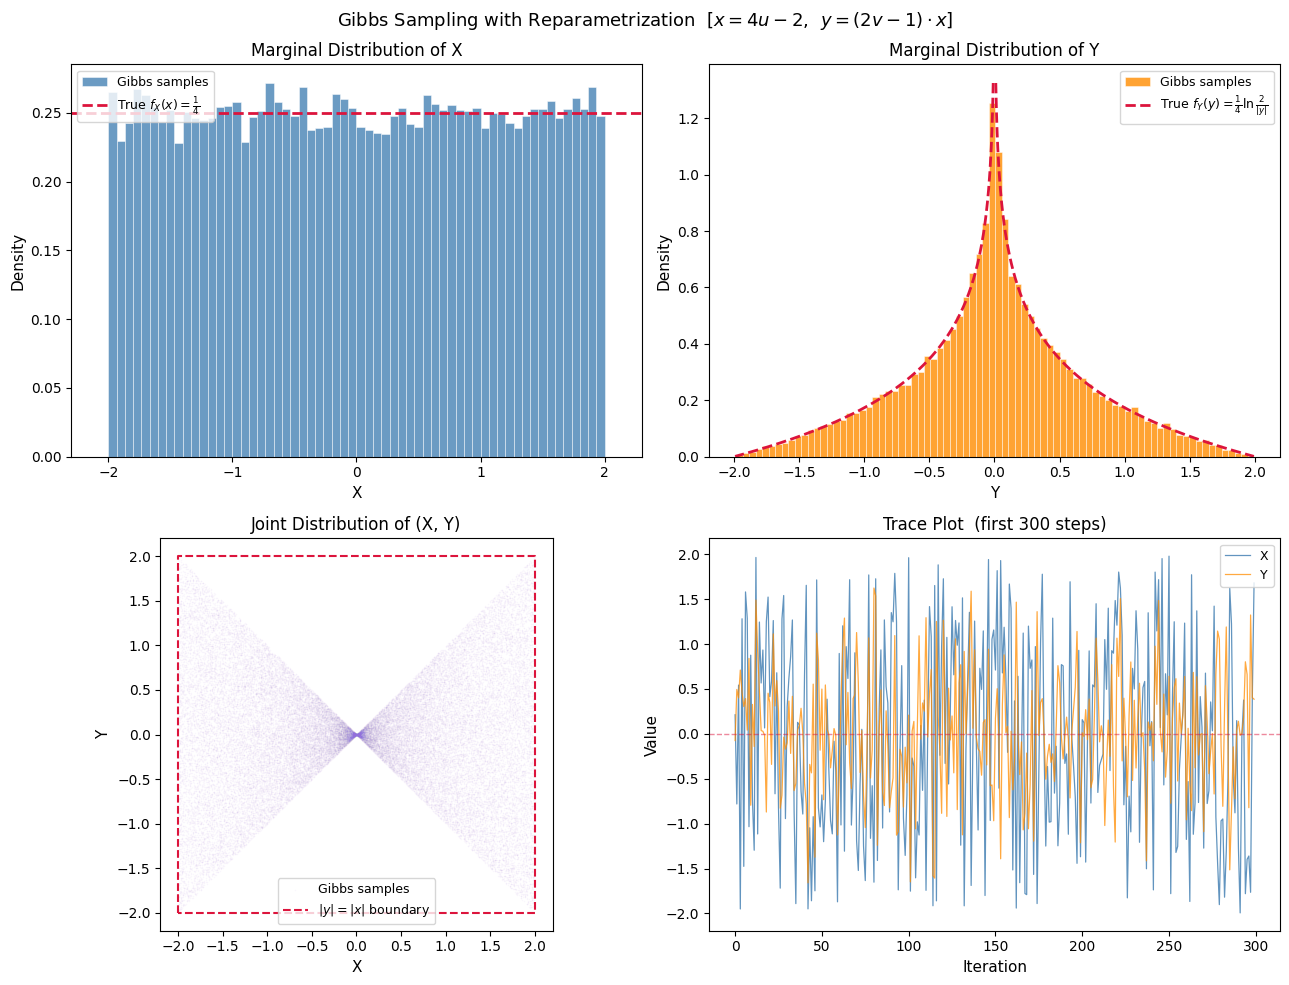

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(
    r"Gibbs Sampling with Reparametrization  "
    r"[$x = 4u-2$,  $y = (2v-1)\cdot x$]",
    fontsize=13,
)

# ── 1. Marginal of X ─────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(xs, bins=60, density=True, color="steelblue", alpha=0.8,
        edgecolor="white", linewidth=0.4, label="Gibbs samples")
ax.axhline(0.25, color="crimson", lw=2, ls="--",
           label=r"True $f_X(x) = \frac{1}{4}$")
ax.set_xlim(-2.3, 2.3)
ax.set_xlabel("X", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Marginal Distribution of X", fontsize=12)
ax.legend(fontsize=9)

# ── 2. Marginal of Y ─────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(ys, bins=80, density=True, color="darkorange", alpha=0.8,
        edgecolor="white", linewidth=0.4, label="Gibbs samples")
y_grid = np.linspace(0.01, 1.99, 400)
true_fy = 0.25 * np.log(2 / y_grid)
ax.plot( y_grid, true_fy, color="crimson", lw=2, ls="--",
        label=r"True $f_Y(y) = \frac{1}{4}\ln\frac{2}{|y|}$")
ax.plot(-y_grid, true_fy, color="crimson", lw=2, ls="--")
ax.set_xlabel("Y", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Marginal Distribution of Y", fontsize=12)
ax.legend(fontsize=9)

# ── 3. Joint scatter ──────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.scatter(xs, ys, s=1, alpha=0.05, color="mediumpurple", linewidths=0,
           label="Gibbs samples")
x_b = np.array([-2, -2, 2, 2, -2])
y_b = np.array([-2,  2, 2, -2, -2])
ax.plot(x_b, y_b, color="crimson", lw=1.5, ls="--", label=r"$|y| = |x|$ boundary")
ax.set_xlabel("X", fontsize=11)
ax.set_ylabel("Y", fontsize=11)
ax.set_title("Joint Distribution of (X, Y)", fontsize=12)
ax.set_aspect("equal")
ax.legend(fontsize=9)

# ── 4. Trace plot ─────────────────────────────────────────────────────────────
ax = axes[1, 1]
n_trace = 300
ax.plot(range(n_trace), xs[:n_trace], color="steelblue",
        lw=0.9, alpha=0.85, label="X")
ax.plot(range(n_trace), ys[:n_trace], color="darkorange",
        lw=0.9, alpha=0.75, label="Y")
ax.axhline(0, color="crimson", lw=1, ls="--", alpha=0.5)
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("Value", fontsize=11)
ax.set_title(f"Trace Plot  (first {n_trace} steps)", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()